Part 1

1)Load data set

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/content/test_zomato.csv")
df.head() #we get shape

,Unnamed: 0,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,0,6317637,Le Petit Souffle,162.0,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,1,6304287,Izakaya Kikufuji,162.0,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,2,6300002,Heat - Edsa Shangri-La,162.0,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,3,6318506,Ooma,162.0,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,4,6314302,Sambo Kojin,162.0,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.58445,...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


2) Explore datasets

In [4]:
df.info() # column names and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9552 entries, 0 to 9551
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            9552 non-null   object 
 1   Restaurant ID         9552 non-null   object 
 2   Restaurant Name       9552 non-null   object 
 3   Country Code          9552 non-null   float64
 4   City                  9552 non-null   object 
 5   Address               9552 non-null   object 
 6   Locality              9551 non-null   object 
 7   Locality Verbose      9551 non-null   object 
 8   Longitude             9551 non-null   object 
 9   Latitude              9551 non-null   object 
 10  Cuisines              9542 non-null   object 
 11  Average Cost for two  9551 non-null   object 
 12  Currency              9551 non-null   object 
 13  Has Table booking     9551 non-null   object 
 14  Has Online delivery   9551 non-null   object 
 15  Is delivering now    

In [5]:
df.isna().sum() #null values

,0
Unnamed: 0,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,1
Locality Verbose,1
Longitude,1
Latitude,1


3) Identify duplicates

In [24]:
duplicates=df[df.duplicated()] # no duplicates found
print(duplicates)

Empty DataFrame
Columns: [Unnamed: 0, Restaurant ID, Restaurant Name, Country Code, City, Address, Locality, Locality Verbose, Longitude, Latitude, Cuisines, Average Cost for two, Currency, Has Table booking, Has Online delivery, Is delivering now, Switch to order menu, Price range, Aggregate rating, Rating color, Rating text, Votes]
Index: []

[0 rows x 22 columns]


4) Average cost to two column datatype conversion

In [6]:
#remove non numerical values from the column and converted to numeric
df=df[pd.to_numeric(df['Average Cost for two'],errors='coerce').notna()]
print(df['Average Cost for two'].unique)
df['Average Cost for two']=pd.to_numeric(df['Average Cost for two'])
print(df['Average Cost for two'].unique)

#converting country code column to object
cols=['Country Code']
df[cols]=df[cols].astype("object")


<bound method Series.unique of 0       1100
1       1200
2       4000
3       1500
4       1500
        ... 
9547      80
9548     105
9549     170
9550     120
9551      55
Name: Average Cost for two, Length: 9550, dtype: object>
<bound method Series.unique of 0       1100
1       1200
2       4000
3       1500
4       1500
        ... 
9547      80
9548     105
9549     170
9550     120
9551      55
Name: Average Cost for two, Length: 9550, dtype: int64>


5) basic statistical analysis

In [7]:
df.describe() #statistical analysis

,Average Cost for two,Price range,Aggregate rating,Votes
count,9550.000000,9550.000000,9550.000000,9550.000000
mean,1199.326387,1.804607,2.666314,156.923037
std,16122.023220,0.905378,1.516447,430.189709
min,0.000000,1.000000,0.000000,0.000000
25%,250.000000,1.000000,2.500000,5.000000
50%,400.000000,2.000000,3.200000,31.000000
75%,700.000000,2.000000,3.700000,131.000000
max,800000.000000,4.000000,4.900000,10934.000000


6) a) How many unique cities?
   b) city have the highest number of restuarents?
   c) Cusine appears most frequently?

In [14]:
from numpy._core.defchararray import count
#unique cities in the dataset
unique_city=df['City'].unique()
unique_cityCount=df['City'].nunique()
print(unique_city)
print(unique_cityCount)


['Makati City' 'Mandaluyong City' 'Pasay City' 'Pasig City' 'Quezon City'
 'San Juan City' 'Santa Rosa' 'Tagaytay City' 'Taguig City' 'Brasí_lia'
 'Rio de Janeiro' 'Sí£o Paulo' 'Albany' 'Armidale' 'Athens' 'Augusta'
 'Balingup' 'Beechworth' 'Boise' 'Cedar Rapids/Iowa City' 'Chatham-Kent'
 'Clatskanie' 'Cochrane' 'Columbus' 'Consort' 'Dalton' 'Davenport'
 'Des Moines' 'Dicky Beach' 'Dubuque' 'East Ballina' 'Fernley' 'Flaxton'
 'Forrest' 'Gainesville' 'Hepburn Springs' 'Huskisson' 'Inverloch'
 'Lakes Entrance' 'Lakeview' 'Lincoln' 'Lorn' 'Macedon' 'Macon' 'Mayfield'
 'Mc Millan' 'Middleton Beach' 'Miller' 'Monroe' 'Montville'
 'Ojo Caliente' 'Orlando' 'Palm Cove' 'Paynesville' 'Penola' 'Pensacola'
 'Phillip Island' 'Pocatello' 'Potrero' 'Princeton' 'Rest of Hawaii'
 'Savannah' 'Singapore' 'Sioux City' 'Tampa Bay' 'Tanunda' 'Trentham East'
 'Valdosta' 'Vernonia' 'Victor Harbor' 'Vineland Station' 'Waterloo'
 'Weirton' 'Winchester Bay' 'Yorkton' 'Abu Dhabi' 'Dubai' 'Sharjah' 'Agra'
 'Ahmed

In [15]:
#City with Highest Restaurent count
city_count=df['City'].value_counts()
cityWithMoreTestaurants=city_count.idxmax()
print(city_count)
print(cityWithMoreTestaurants)

City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
                  ... 
Lakes Entrance       1
Mohali               1
Panchkula            1
Bandung              1
Randburg             1
Name: count, Length: 141, dtype: int64
New Delhi


In [17]:
#Highest Cuisine count
cuisine_count=df['Cuisines'].value_counts()
cuisineWithMoreCount=cuisine_count.idxmax()
print(cuisine_count)
print(cuisineWithMoreCount)

Cuisines
North Indian                          936
North Indian, Chinese                 511
Fast Food                             354
Chinese                               354
North Indian, Mughlai                 334
                                     ... 
World Cuisine, Patisserie, Cafe         1
Burger, Izgara                          1
Desserts, Bí_rek                        1
Restaurant Cafe, Turkish, Desserts      1
Restaurant Cafe, Desserts               1
Name: count, Length: 1825, dtype: int64
North Indian


Part 2

In [20]:
#removed null values with "Unknown" in the Cusines column
df.isna().sum()
df['Cuisines']=df['Cuisines'].fillna("Unknown")

1)Average Restaurent Rating

In [22]:
avg_restuarentRating=df['Aggregate rating'].mean()
print(avg_restuarentRating)

2.666314136125654


2) Restuarents with highest number of votes

In [25]:
df.loc[df['Votes'].idxmax(),['Restaurant Name','Votes']]

,729
Restaurant Name,Toit
Votes,10934.0


3) Avg COst of Two

In [26]:
avg_cost=df['Average Cost for two'].mean()
print(avg_cost)

1199.326387434555


4) COmapre avg rateing of Restuarent online and not have online delivery

In [29]:
#online
avg_onlineRateing=df.groupby('Has Online delivery')['Aggregate rating'].mean()
print(avg_onlineRateing)

Has Online delivery
No     2.465192
Yes    3.248837
Name: Aggregate rating, dtype: float64


5) Comapre avg rateing of restaurents have table booking and not have

In [31]:
avg_onlineRateingTableBooking=df.groupby('Has Table booking')['Aggregate rating'].mean()
print(avg_onlineRateingTableBooking)

Has Table booking
No     2.559283
Yes    3.441969
Name: Aggregate rating, dtype: float64


6) top 10 cities with highest number of restuarents

In [34]:
city_count=df['City'].value_counts().head(10)
print(city_count)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


In [48]:
topCity=df['City'].value_counts().idxmax()
topCusine=df['Cuisines'].value_counts().idxmax()

Part 3 - Data Visualization

1) Bar chart top 10 cities with highest number of restaurents

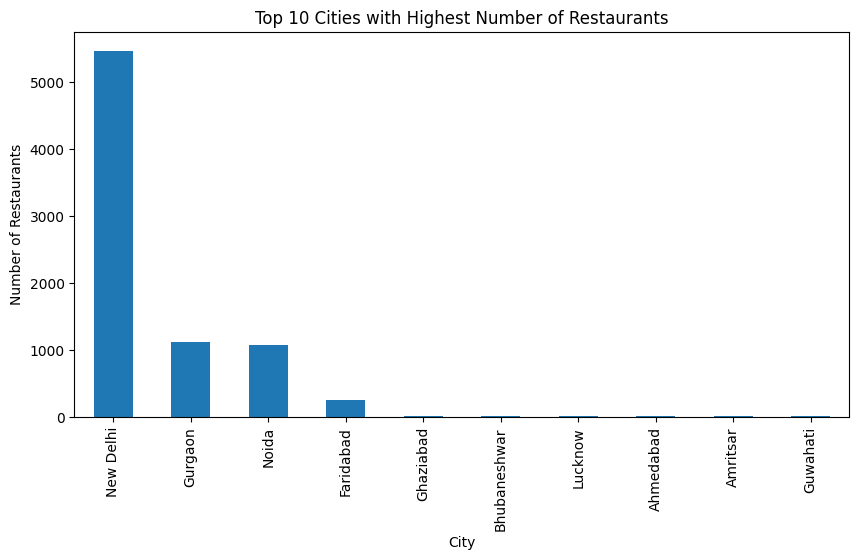

In [35]:
plt.figure(figsize=(10,5))
city_count.plot(kind='bar')
plt.title('Top 10 Cities with Highest Number of Restaurants')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.show()

2. Histogram Distribution of Aggregate ratings

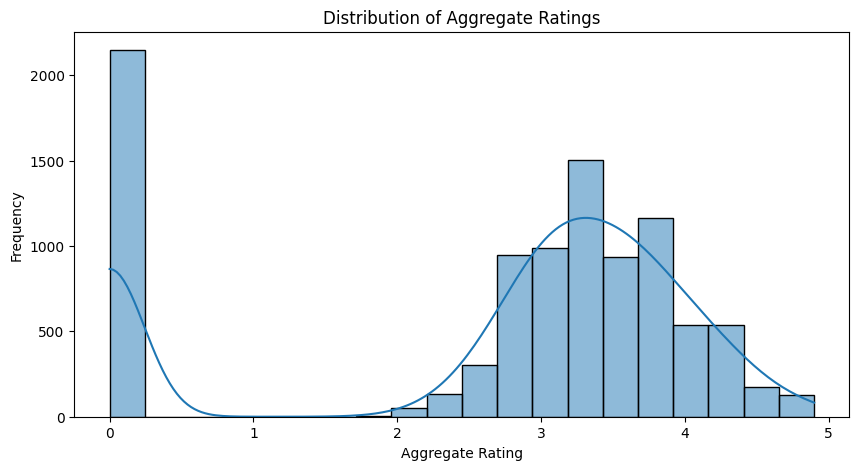

In [36]:
plt.figure(figsize=(10,5))
sns.histplot(df['Aggregate rating'],bins=20,kde=True)
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Frequency')
plt.show()

3) Bar Chart Number of restuarents offering Online delivery? (Yes,No)

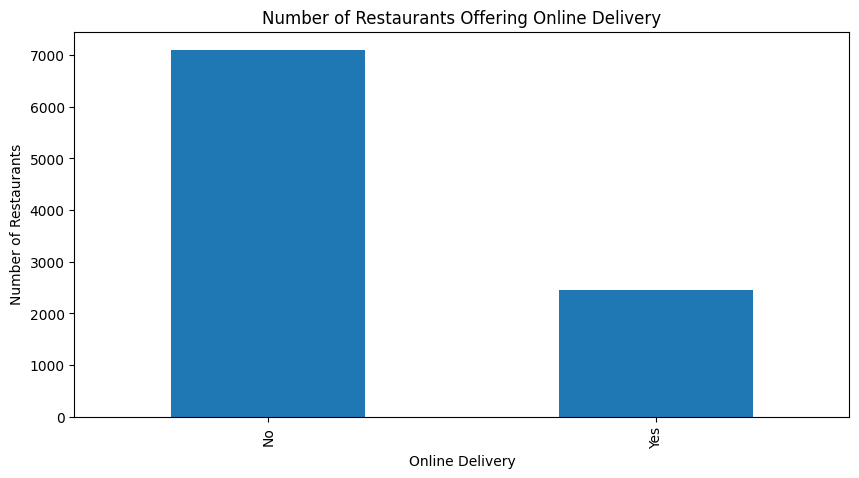

In [37]:
plt.figure(figsize=(10,5))
df['Has Online delivery'].value_counts().plot(kind='bar')
plt.title('Number of Restaurants Offering Online Delivery')
plt.xlabel('Online Delivery')
plt.ylabel('Number of Restaurants')
plt.show()

4) Bar Chart Top 10 most common cusines

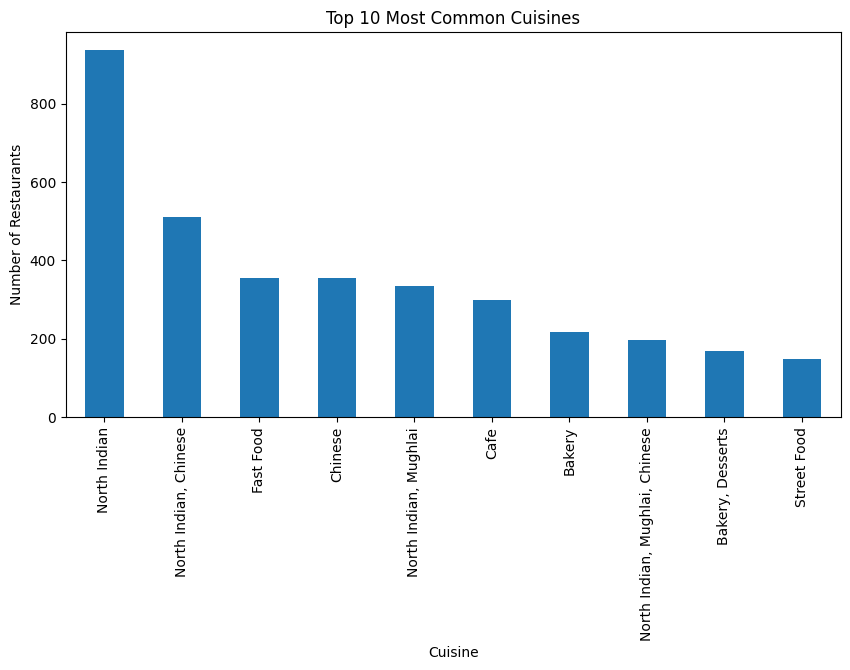

In [38]:
plt.figure(figsize=(10,5))
df['Cuisines'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Most Common Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.show()

5) Line chart Average restaurent ratings by price range

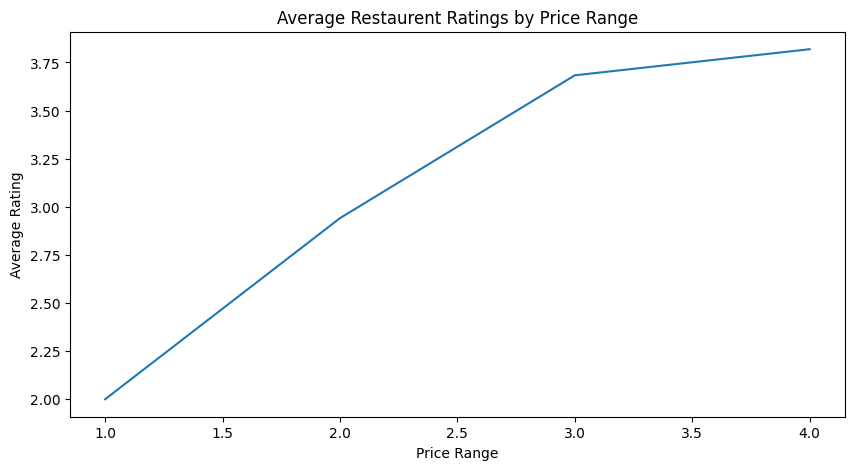

In [39]:
plt.figure(figsize=(10,5))
df.groupby('Price range')['Aggregate rating'].mean().plot(kind='line')
plt.title('Average Restaurent Ratings by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Rating')
plt.show()

Part 4 - Business Insights


In [53]:
print(f"1. city - highest restaurent presence - {topCity}")
print(f"2. Most Popular Cuisine - {topCusine}")
print(f"3. Restuarents with online delivery has highest rateing- {avg_onlineRateing}")
print(f"4. Restuarents with table booking has highest rateing- {avg_onlineRateingTableBooking}")
print(f"5. Restuarents with online delivery has highest rateing, restaurent distribution is concentrated in fewer cities")


1. city - highest restaurent presence - New Delhi
2. Most Popular Cuisine - North Indian
3. Restuarents with online delivery has highest rateing- Has Online delivery
No     2.465192
Yes    3.248837
Name: Aggregate rating, dtype: float64
4. Restuarents with table booking has highest rateing- Has Table booking
No     2.559283
Yes    3.441969
Name: Aggregate rating, dtype: float64
5. Restuarents with online delivery has highest rateing, restaurent distribution is concentrated in fewer cities
